In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
from scipy import signal
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter

# データの読み込み

## 歩行軌跡と歩行速度

In [2]:
trajectory_file_path = "./data/trajectory.csv"
speed_file_path = "./data/speed.csv"

# 通信してデータを取得
df_trajectory = pd.read_csv(trajectory_file_path)
df_speed = pd.read_csv(speed_file_path)

## データの描画

### 歩行軌跡

<Figure size 640x480 with 0 Axes>

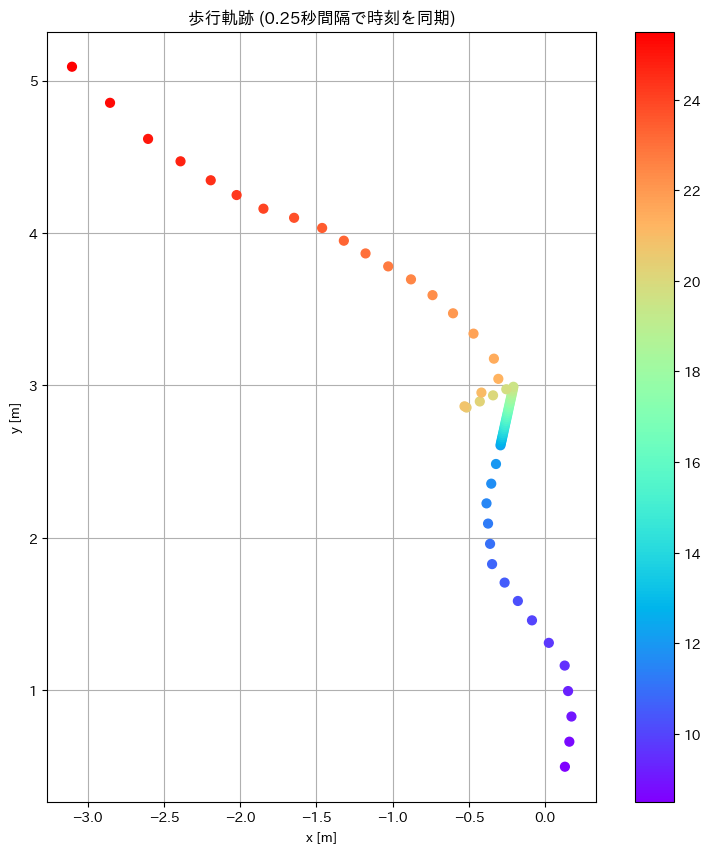

In [3]:
plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

x = df_trajectory['x']
y = df_trajectory['y'] 
time = df_trajectory['time']

# 補間された軌跡を描画
plt.colorbar(plt.scatter(x, y,c=time,cmap='rainbow',s=40, label=f'推定軌跡', zorder=2))

plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (0.25秒間隔で時刻を同期)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)

plt.show()


## timeが15.0~27.0だけ抽出

<Figure size 640x480 with 0 Axes>

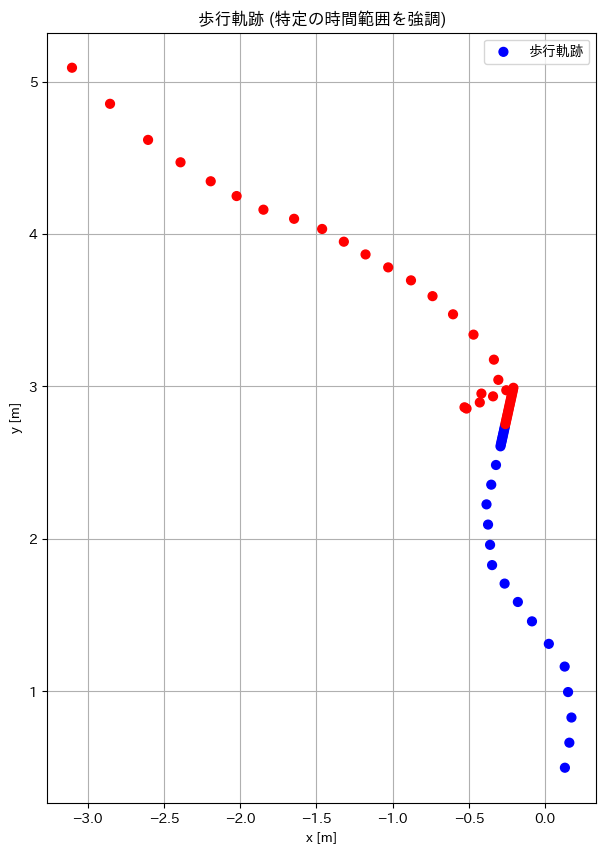

In [4]:
# timeが15秒から27秒の範囲にあるかどうかで色を決定
colors = np.where((df_trajectory['time'] >= 15) & (df_trajectory['time'] <= 27), 'red', 'blue')


plt.subplots_adjust(hspace=0.3)
fig = plt.figure(figsize=(10, 10))

# 特定の時間範囲の点を強調（例：赤色）
plt.scatter(df_trajectory['x'], df_trajectory['y'], c=colors, s=40, label='歩行軌跡', zorder=2)


plt.gca().set_aspect('equal', adjustable='box')
plt.title('歩行軌跡 (特定の時間範囲を強調)')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.grid(True)
plt.legend() # ラベルを表示するために凡例を追加
plt.show()

### 歩行速度

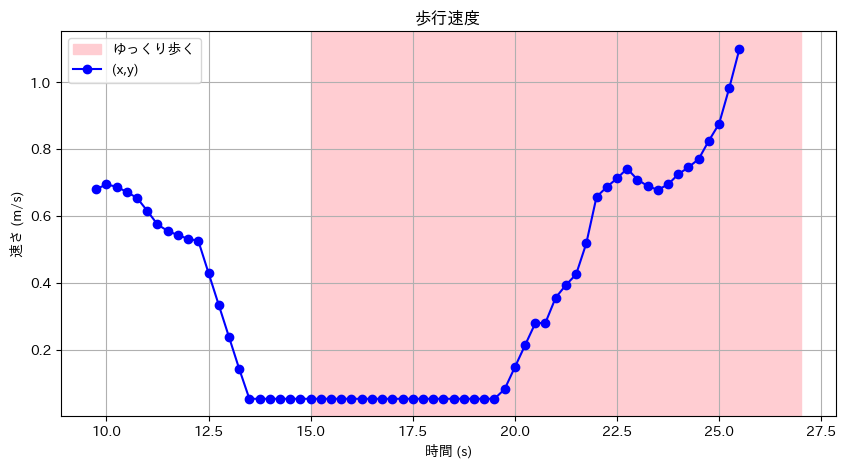

In [5]:
# ~speed.csvに1行目にデータ_足す(time,speed)[1]=(?,0)
# 軌跡と速度のtimeを同期するため
speed = df_speed['low_speed'] 
time = df_speed['time']
plt.figure(figsize=(10, 5))
plt.axvspan(15.0, 27.0,alpha=1.0,color="#ffcdd2",label='ゆっくり歩く')
plt.plot(time,speed, marker='o', linestyle='-', color='blue', label='(x,y)')
plt.xlabel('時間 (s)')
plt.ylabel('速さ (m/s)')
plt.title('歩行速度')
plt.grid(True)
plt.legend()

plt.show()

# データのラベル付け/抽出ロジック

     time         x         y     speed   stay
0    8.50  0.129588  0.499337       NaN  False
1    8.75  0.158754  0.663551  0.667136  False
2    9.00  0.172543  0.828617  0.662566  False
3    9.25  0.150316  0.995681  0.674141  False
4    9.50  0.128090  1.162744  0.674141  False
..    ...       ...       ...       ...    ...
64  24.50 -2.193575  4.345983  0.782015  False
65  24.75 -2.391646  4.470410  0.935641  False
66  25.00 -2.604473  4.617386  1.034582  False
67  25.25 -2.853966  4.854073  1.375602  False
68  25.50 -3.103459  5.090761  1.375602  False

[69 rows x 5 columns]


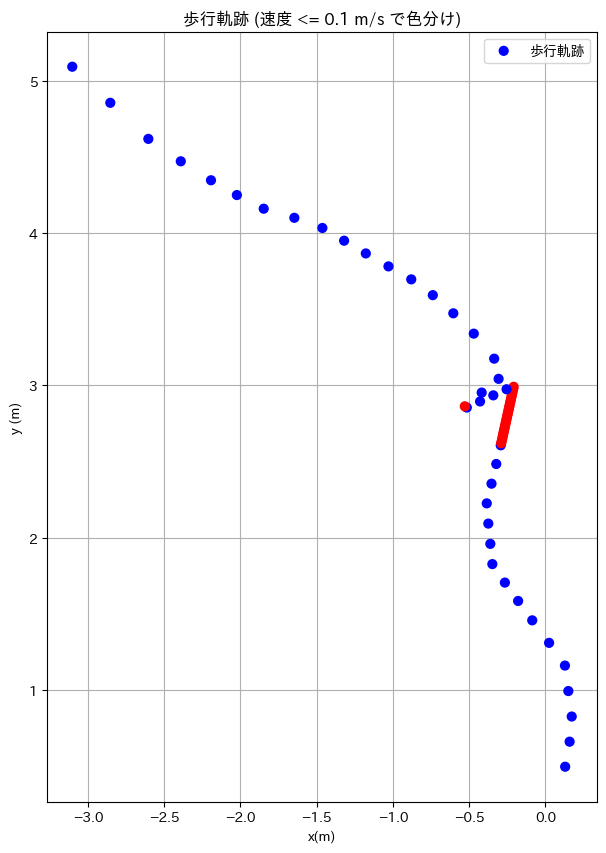

In [6]:
# 時間軸での同期: 歩行軌跡データと歩行速度データは、同じ時間点に対応しているか
df_trajectory = pd.merge(df_trajectory, df_speed[['time', 'speed']], on='time', how='left')

# 閾値の設定
# 条件判定: 歩行速度が設定された閾値以下であるか
threshold = 0.1
df_trajectory['stay'] = df_trajectory['speed'] <= threshold
print(df_trajectory)

colors_by_speed = np.where(df_trajectory['speed'] <= threshold, 'red', 'blue')

plt.figure(figsize=(10, 10))

# 閾値以下の場合、赤くそれ以外は青くプロット
plt.scatter(df_trajectory['x'], df_trajectory['y'], c=colors_by_speed, s=40, label='歩行軌跡', zorder=2)
df_trajectory.to_csv('data/threshold_trajectory_data.csv', index=False)

# 閾値以下の点をプロット
# plt.scatter(df_trajectory[df_trajectory['threshold_speed']]['x'],
#             df_trajectory[df_trajectory['threshold_speed']]['y'],
# 			c=colors_by_speed,
#             s=40, label=f'速度 <= {threshold} m/s', zorder=2)


plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x(m)')
plt.ylabel('y (m)')
plt.title(f'歩行軌跡 (速度 <= {threshold} m/s で色分け)')
plt.grid(True)
plt.legend()
plt.show()